<a href="https://colab.research.google.com/github/jooyoung227/ESAA-14-23-/blob/main/ESAA_jooyoung_YB_0525_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#07_03 평균 이동
###평균 이동(Mean Shift)의 개요
 K-평균과 유사하게 중심을 군집의 중심으로 지속적으로 움직이면서 군집화를 수행  
평균
이동은 중심을 데이터가 모여 있는 밀도가 가장 높은 곳으로 이동  이를 위해 확률 밀도 함수(probability density
function)를 이용  
평균 이동 군집화는 특정 데이터를 반경 내의 데이터 분포 확률 밀도가 가장 높은 곳으로 이동하기 위
해 주변 데이터와의 거리 값을 KDE 함수 값으로 입력한 뒤 그 반환 값을 현재 위치에서 업데이트하면
서 이동하는 방식
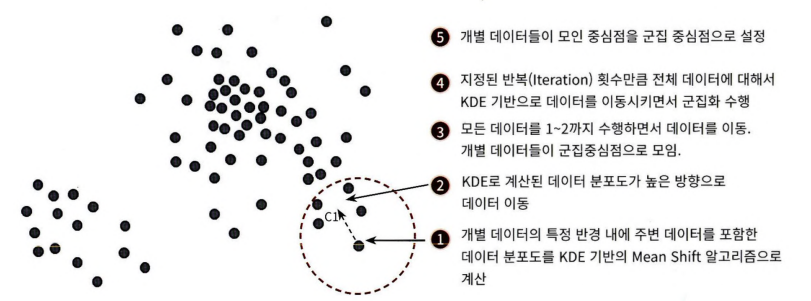

KDE(Kernel Density Estimation)는 커널(Kern이) 함수를 통해 어떤 변수의 확률 밀도 함수를 추정
하는 대표적인 방법  
KDE는 개별 관측 데이터에 커널 함수를 적용한 뒤, 이 적용 값을 모두 더한 후 개별 관측 데이터의 건
수로 나눠 확률 밀도 함수를 추정하며, 대표적인 커널 함수로서 가우시안 분포 함수가 사용
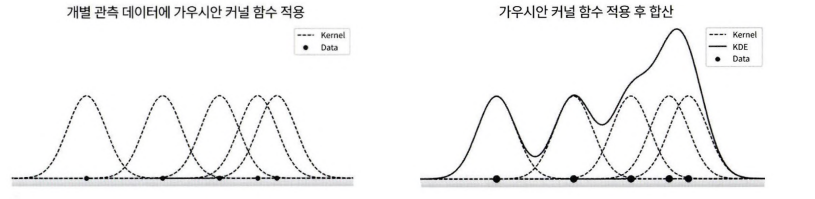

대역폭 오는 KDE 형태를 부드러운(또는 뾰족한) 형태로 평활화(Smoothing)하는 데 적용되며, 이 h
를 어떻게 설정하느냐에 따라 확률 밀도 추정 성능을 크게 좌우  
일반적으로 평균 이동 군집화는 대역폭이 클수록 평활화된 KDE로 인해 적은 수의 군집 중심점을 가지
며 대역폭이 적을수록 많은 수의 군집 중심점을 가집니다. 또한 평균 이동 군집화는 군집의 개수를 지
정하지 않으며, 오직 대역폭의 크기에 따라 군집화를 수행합니다.
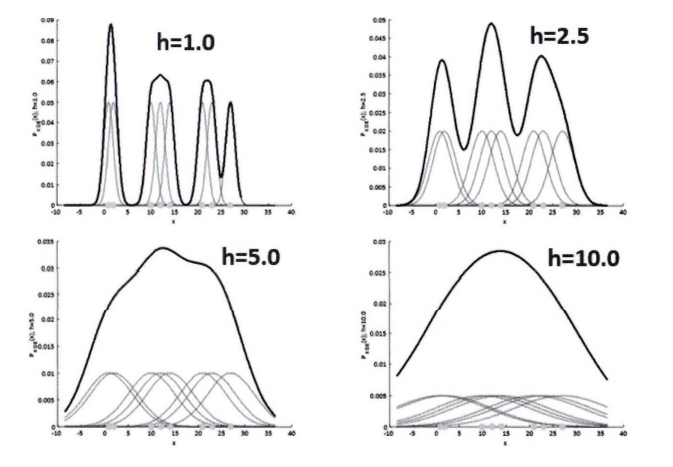

In [1]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift

X, y = make_blobs(
    n_samples=200,
    n_features=2,
    centers=3,
    cluster_std=0.7,
    random_state=0
)

meanshift = MeanShift(bandwidth=0.8)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2 3 4 5]


In [2]:
meanshift = MeanShift(bandwidth=1)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2]


In [3]:
from sklearn.cluster import estimate_bandwidth

bandwidth = estimate_bandwidth(X)
print('bandwidth 값:', round(bandwidth, 3))


bandwidth 값: 1.816


In [4]:
import pandas as pd

clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y

# estimate_bandwidth()로 최적의 bandwidth 계산
best_bandwidth = estimate_bandwidth(X)

meanshift = MeanShift(bandwidth=best_bandwidth)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2]


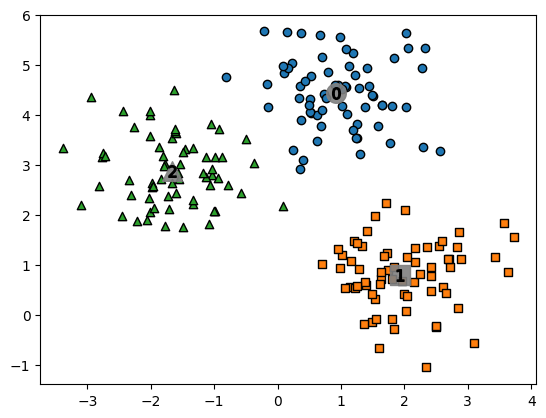

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

clusterDF['meanshift_label'] = cluster_labels
centers = meanshift.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ['o', 's', '^', 'x', '*']

for label in unique_labels:
    label_cluster = clusterDF[clusterDF['meanshift_label'] == label]
    center_x_y = centers[label]

    # 군집별로 다른 마커로 산점도 적용
    plt.scatter(
        x=label_cluster['ftr1'],
        y=label_cluster['ftr2'],
        edgecolor='k',
        marker=markers[label]
    )

    # 군집별 중심 표현
    plt.scatter(
        x=center_x_y[0],
        y=center_x_y[1],
        s=200,
        color='gray',
        alpha=0.9,
        marker=markers[label]
    )

    plt.scatter(
        x=center_x_y[0],
        y=center_x_y[1],
        s=70,
        color='k',
        edgecolor='k',
        marker='$%d$' % label
    )

plt.show()

In [6]:
print(clusterDF.groupby('target')['meanshift_label'].value_counts())

target  meanshift_label
0       0                  67
1       1                  67
2       2                  66
Name: count, dtype: int64


#07_04 GMM(Gaussian Mixture Model)
###GMM(Gaussian Mixture Model) 소개
GMM 군집화는 군집화를 적용하고자 하는 데이터가 여러 개의 가우시안 분포(GaussianDistri
bution)를 가진 데이터 집합들이 섞여서 생성된 것이라는 가정하에 군집화를 수행하는 방식  
GMM(Gaussian Mixture Model)은 데이터를 여러 개의 가우시안 분포가 섞인 것으로 간주합니다.
섞인 데이터 분포에서 개별 유형의 가우시안 분포를 추출

###GMM을 이용한 붓꽃 데이터 세트 군집화

In [7]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# 좀 더 편리한 데이터 handling을 위해 DataFrame으로 변환
irisDF = pd.DataFrame(data=iris.data, columns=feature_names)
irisDF['target'] = iris.target

In [8]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=0).fit(iris.data)
gmm_cluster_labels = gmm.predict(iris.data)

# 군집화 결과를 irisDF의 'gmm_cluster' 칼럼명으로 저장
irisDF['gmm_cluster'] = gmm_cluster_labels
irisDF['target'] = iris.target

# target 값에 따라 gmm_cluster 값이 어떻게 매핑됐는지 확인
iris_result = irisDF.groupby(['target'])['gmm_cluster'].value_counts()
print(iris_result)

target  gmm_cluster
0       1              50
1       0              45
        2               5
2       2              50
Name: count, dtype: int64


In [9]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0).fit(iris.data)
kmeans_cluster_labels = kmeans.predict(iris.data)

irisDF['kmeans_cluster'] = kmeans_cluster_labels

iris_result = irisDF.groupby(['target'])['kmeans_cluster'].value_counts()
print(iris_result)

target  kmeans_cluster
0       1                 50
1       0                 47
        2                  3
2       2                 36
        0                 14
Name: count, dtype: int64


###GMM과 K—평균의 비교
KMeans는 원형의 범위에서 군집화를 수행합니다. 데이터 세트가 원형의 범위를 가질수록 KMeans의
군집화 효율은 더욱 높아집니다.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import make_blobs

%matplotlib inline


def visualize_cluster_plot(cluster_result=None, dataframe=None, label_name='target', iscenter=True):
    if dataframe is None:
        print("Error: DataFrame is required.")
        return

    unique_labels = np.unique(dataframe[label_name])
    markers = ['o', 's', '^', 'x', '*', 'D', '+', 'v', '<', '>']

    for label in unique_labels:
        label_cluster = dataframe[dataframe[label_name] == label]

        plt.scatter(
            x=label_cluster['ftr1'],
            y=label_cluster['ftr2'],
            edgecolor='k',
            marker=markers[label % len(markers)]
        )

        if iscenter and cluster_result is not None and hasattr(cluster_result, 'cluster_centers_'):
            center_x_y = cluster_result.cluster_centers_[label]

            plt.scatter(
                x=center_x_y[0],
                y=center_x_y[1],
                s=200,
                color='gray',
                alpha=0.9,
                marker=markers[label % len(markers)]
            )

            plt.scatter(
                x=center_x_y[0],
                y=center_x_y[1],
                s=70,
                color='k',
                edgecolor='k',
                marker='$%d$' % label
            )

    plt.show()

In [11]:
from sklearn.datasets import make_blobs

# make_blobs()로 300개의 데이터 세트, 3개의 군집 세트, cluster_std=0.5로 만듦
X, y = make_blobs(
    n_samples=300,
    n_features=2,
    centers=3,
    cluster_std=0.5,
    random_state=0
)

# 길게 늘어난 타원형의 데이터 세트를 생성하기 위해 변환함
transformation = [[0.60834549, -0.63667341],
                  [-0.40887718, 0.85253229]]

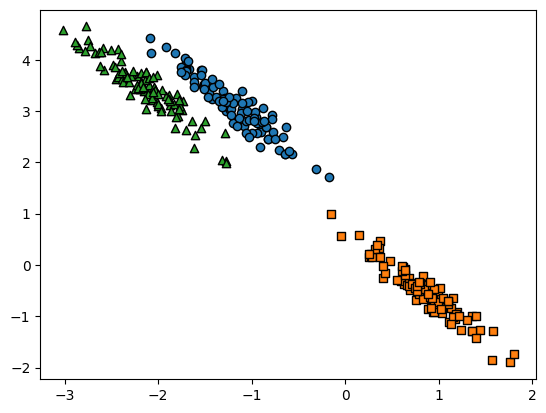

In [12]:
X_aniso = np.dot(X, transformation)

# feature 데이터 세트와 make_blobs()의 y 결과값을 DataFrame으로 저장
clusterDF = pd.DataFrame(data=X_aniso, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y

# 생성된 데이터 세트를 target별로 다른 마커로 표시해 시각화
visualize_cluster_plot(None, clusterDF, 'target', iscenter=False)

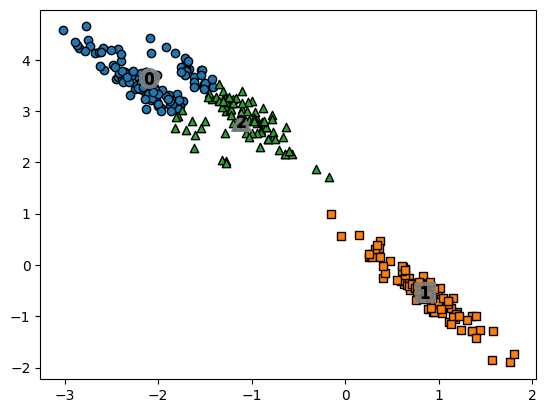

In [13]:
# 3개의 군집 기반 KMeans를 X_aniso 데이터 세트에 적용
kmeans = KMeans(3, random_state=0)
kmeans_label = kmeans.fit_predict(X_aniso)

clusterDF['kmeans_label'] = kmeans_label

visualize_cluster_plot(kmeans, clusterDF, 'kmeans_label', iscenter=True)

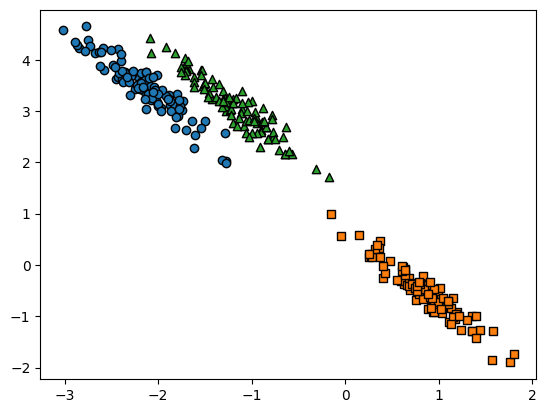

In [14]:
# 3개의 n_components 기반 GMM을 X_aniso 데이터 세트에 적용
gmm = GaussianMixture(n_components=3, random_state=0)
gmm_label = gmm.fit(X_aniso).predict(X_aniso)

clusterDF['gmm_label'] = gmm_label

# GaussianMixture는 cluster_centers_ 속성이 없으므로 iscenter를 False로 설정
visualize_cluster_plot(gmm, clusterDF, 'gmm_label', iscenter=False)

In [15]:
print('### KMeans Clustering ###')
print(clusterDF.groupby('target')['kmeans_label'].value_counts())

print('\n### Gaussian Mixture Clustering ###')
print(clusterDF.groupby('target')['gmm_label'].value_counts())

### KMeans Clustering ###
target  kmeans_label
0       2                73
        0                27
1       1               100
2       0                86
        2                14
Name: count, dtype: int64

### Gaussian Mixture Clustering ###
target  gmm_label
0       2            100
1       1            100
2       0            100
Name: count, dtype: int64
